# 3. Post Processing 

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import median_filter
from scipy.stats import binned_statistic
from pathlib import Path

# PlatoSim libraries
import platosim.utilities as ut
from platosim.hpc          import HPC
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
# Global paths
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
sdir = path / 'simulations/sims'
vdir = path / 'varsource'
fdir = path / 'figures'

---
## Reduction example
---

In [27]:
# Directory to store and load simulations
filename = 'spikey_omega000'
odir = sdir / filename

# Load variable source file and add flux column [ppt]
varfile = vdir / 'varsource_spikey_omega000.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400
dv = dv.loc[::144]

### Run parallel simulations

We ran the simulations with the script `run_hpc.py` in the project folder since it goes faster than through Jupyter.

In [21]:
# # Arguments to parse
# kwargs = (f'--field LOPN1 --sample KIC011606854 ' +
#           f'--cadence 500 --mag 15 --nocon ' +
#           f'--seed 12345 --varfile {varfile} -w')

# # Launch simulations
# hpc = HPC('smbhb', cpus=6)
# hpc.run(script='platonium', param_file='cluster.data', odir=odir, kwargs=kwargs) 

### Data quick look

In [13]:
# Load light curves
lcs = LightCurve(odir, mode="multi")
files = lcs.files(suffix='hdf5')
len(files)

384

<IPython.core.display.Javascript object>


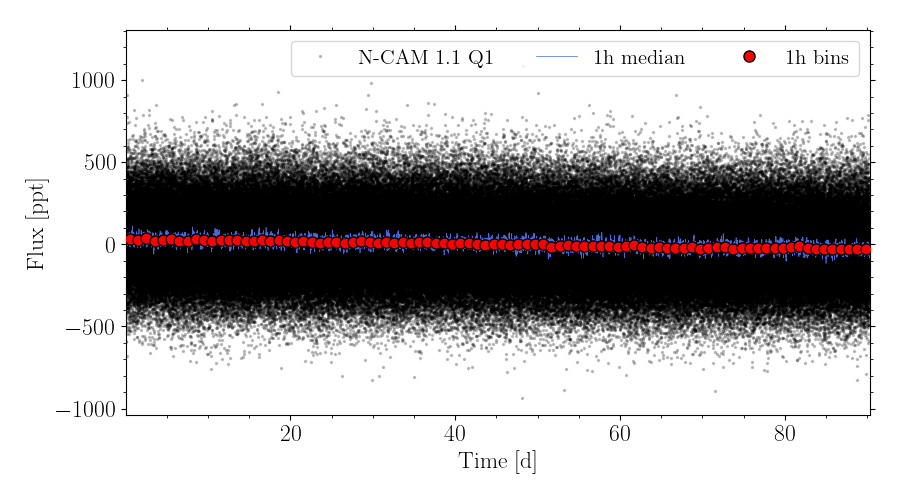

In [14]:
# Show a single light curve
lc = LightCurve(files[0], mode="single")
lc.plot(flux_unit='ppt', binsize=1, median_filter=1);

<IPython.core.display.Javascript object>


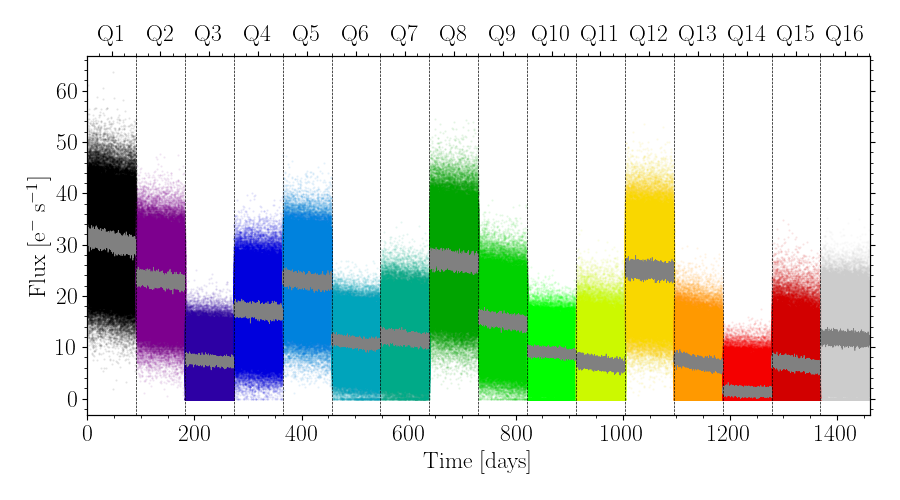

In [16]:
# Show all light curves from one group
fig, ax = lcs.plot_multi(suffix='hdf5', group=1, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

### Post-process a single camera light curve

In [17]:
# Load light curves of a single camera
lcs = LightCurve(odir, mode="multi")
files = lcs.files('hdf5', group=3, camera=1)
cadence = 25
binsize = 600
quarter = 16
nexp_per_quarter = 312113
nexp_per_bin = int(np.ceil(nexp_per_quarter * cadence / binsize))
mask_updates = np.arange(0, (quarter+1)*nexp_per_bin, nexp_per_bin).tolist()

In [18]:
# Merge all quarters
df0 = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1 = lc.bin(binsize=binsize/3600, time_unit='h')
    # Only allow flux measurements above threshold
    if df1.flux.median() < 5:
        df1.flux = np.ones_like(df1.flux.to_numpy) * np.nan
    else:
        df1.flux /= df1.flux.median() 
    # Store data frames
    df1.time *= 3600
    df0 = pd.concat([df0, df1])    
# Deep copy of base flux
df0['flux_base'] = df0.flux

<IPython.core.display.Javascript object>


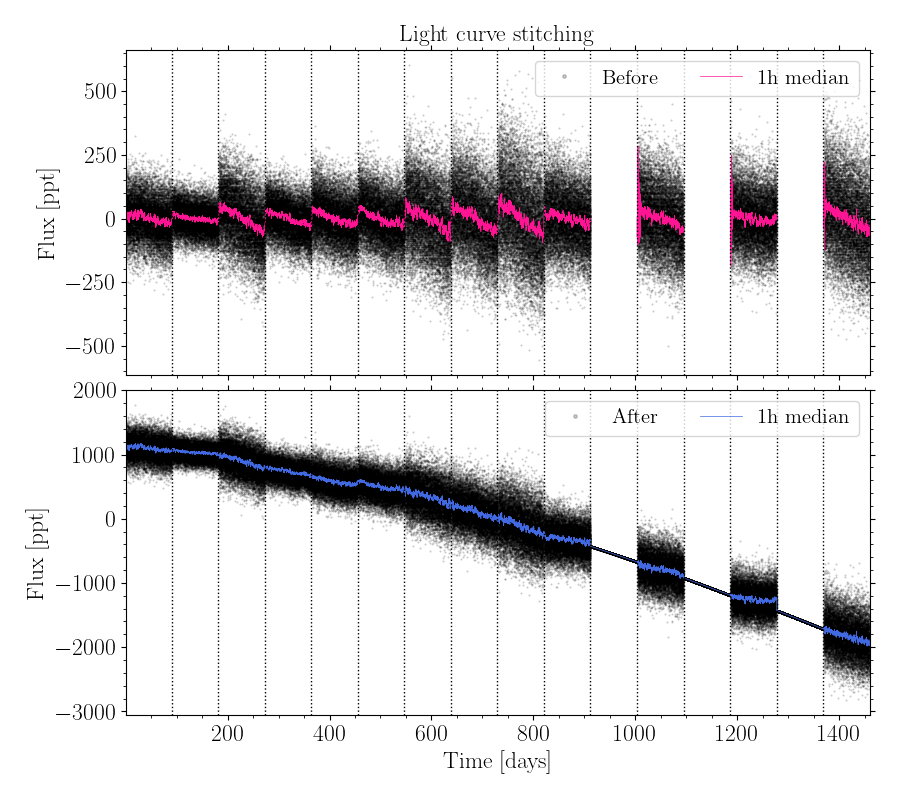

,time,flux,flux_base,flux_stitch,flux0
0,306.242311,1.067511,1.067511,1.067511,1.067511
1,906.226932,1.035443,1.035443,1.035443,1.035443
2,1506.211553,1.035443,1.035443,1.035443,1.035443
3,2106.196175,0.949367,0.949367,0.949367,0.949367
4,2706.180796,1.097891,1.097891,1.097891,1.097891


In [19]:
# Stitch the light curve
lc = LightCurve(df0, mode="multi")
df = lc.stitch(method='lowess', segment=5, mask_updates=mask_updates, plot=True)
df.head()

<IPython.core.display.Javascript object>


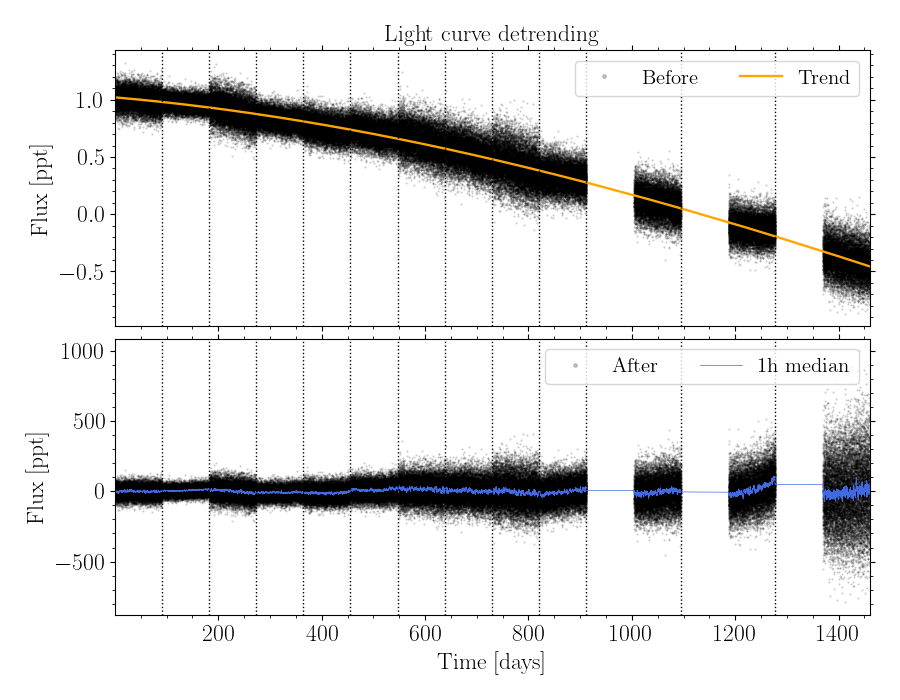

,time,flux,flux_base,flux_stitch,flux0,flux_trend,flux_detrend
0,306.242311,1.067511,1.067511,1.067511,1.067511,1.021491,1.022766
1,906.226932,1.035443,1.035443,1.035443,1.035443,1.021488,1.006903
2,1506.211553,1.035443,1.035443,1.035443,1.035443,1.021485,1.006905
3,2106.196175,0.949367,0.949367,0.949367,0.949367,1.021482,0.964325
4,2706.180796,1.097891,1.097891,1.097891,1.097891,1.021480,1.037800


In [20]:
# Linear detrend
df = lc.detrend(column='flux_stitch', model='poly', poly_degree=3, segments=False, plot=True)
df.head()

<IPython.core.display.Javascript object>


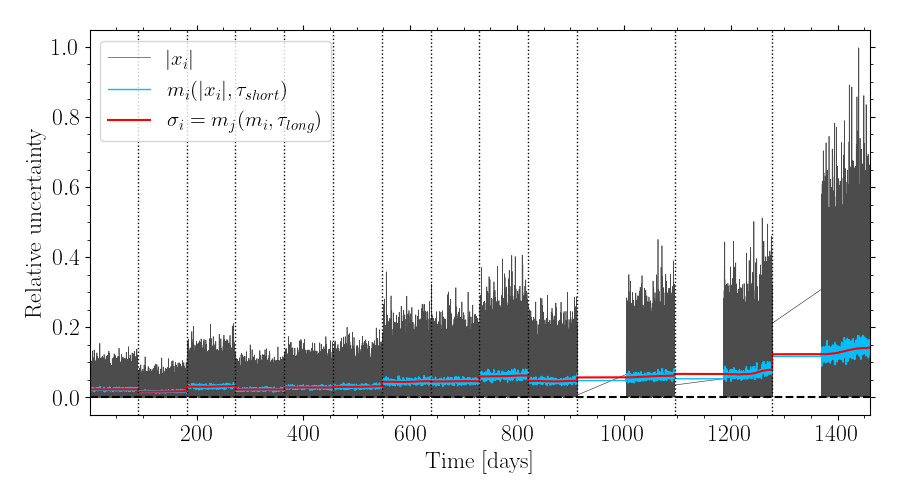

In [21]:
# Compute flux errors
df = lc.flux_error(column='flux_detrend', plot=True, short_filter=0.5, long_filter=50, type_filter=np.std)

<IPython.core.display.Javascript object>


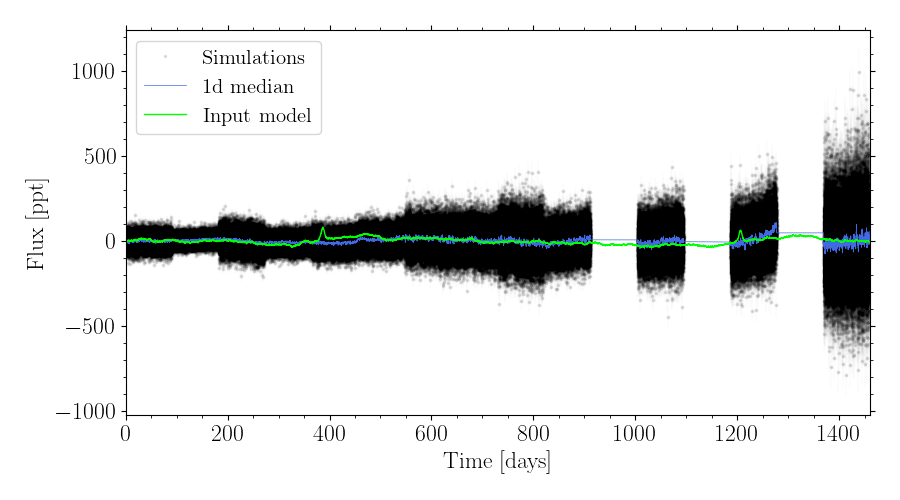

In [22]:
# Plot camera light curve with errors
time = df.time / 86400
flux = (df.flux_detrend - 1) * 1e3
ferr = df.flux_err * 1e3
fmed = median_filter(flux, 144)
fig = plt.figure(figsize=(9,5))
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.01, zorder=1)
plt.plot(time, flux, 'k.', ms=3, alpha=0.1, zorder=1, label='Simulations')
plt.plot(time, fmed, '-', c='royalblue', lw=0.5, label='1d median')
plt.plot(dv.time, dv.flux, '-', c='lime', lw=1.0, label='Input model')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(0, time.max())
plt.legend(loc='best')
plt.tight_layout();

### Post-process to final light curves

In [23]:
def merge(lcs, cadence=25, binsize=600, quarters=16, segment=5, poly_degree=2, flux_thres=5):
    # Combine the two datasets while reducing each
    hour = 3600
    nexp_per_quarter = 312113
    nexp_per_bin = int(np.ceil(nexp_per_quarter * cadence / binsize))
    mask_updates = np.arange(0, (quarters + 1)*nexp_per_bin, nexp_per_bin).tolist()
    # Loop over each camera in each group
    dx = pd.DataFrame()
    for g in range(1,5):
        for c in tqdm(range(1,7), bar_format=ut.tqdmBar(), desc=f'Group {g}'):  
            # Merge all quarters
            df0 = pd.DataFrame()
            df1 = pd.DataFrame()
            files = lcs.files('hdf5', group=g, camera=c)
            for f in files:
                lc = LightCurve(f)
                df1 = lc.bin(binsize=binsize/hour, time_unit='h')
                # Only allow flux measurements above threshold [e-/s]
                if df1.flux.median() < flux_thres:
                    df1.flux = np.ones_like(df1.flux.to_numpy) * np.nan
                else:
                    df1.flux /= df1.flux.median() 
                # Store data frames
                df1.time *= hour 
                df0 = pd.concat([df0, df1])
            # Post-process full camera light curve
            lc = LightCurve(df0, mode="multi")
            lc.stitch(method='lowess', segment=segment, mask_updates=mask_updates)
            df = lc.detrend(column='flux_stitch', model='poly', poly_degree=poly_degree, 
                            segments=False, replace=True)
            df = lc.flux_error(short_filter=0.5, long_filter=50)
            dx = pd.concat([dx, df])  
    # Weighted average across equal timings
    dx = dx.reset_index()
    dx = dx.sort_values(by=['time'])
    dx['weight'] = 1 / dx.flux_err**2
    w = lambda x: np.average(x, weights=dx.loc[x.index, "weight"])
    e = lambda x: np.sqrt(1 / np.sum(dx.loc[x.index, "weight"])) 
    dx = dx.groupby(['time']).agg(flux=('flux', w), flux_err=('flux_err', e))
    dx = dx.reset_index()
    # Bin date to final light curve
    tbin = 3600
    tdur = dx.time.iloc[-1] - dx.time.iloc[0]
    bins = int(tdur/tbin)
    flux_bin, time_bin, _= binned_statistic(dx.time, dx.flux,     'median', bins)
    flux_err, time_bin, _= binned_statistic(dx.time, dx.flux_err, 'median', bins)
    flux_med = median_filter(flux_bin, 24)
    time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.
    dx = pd.DataFrame({'time':time_bin, 'flux':flux_bin, 'flux_med':flux_med, 'flux_err':flux_err})
    return dx

In [24]:
# Generate merged final light curve
lcs = LightCurve(odir, mode="multi")
df = merge(lcs, poly_degree=3, flux_thres=5)

Group 4: 100%|██████████████████████████████████████████████████| 6/6 [03:42<00:00, 37.08s/it]                                                                


<IPython.core.display.Javascript object>


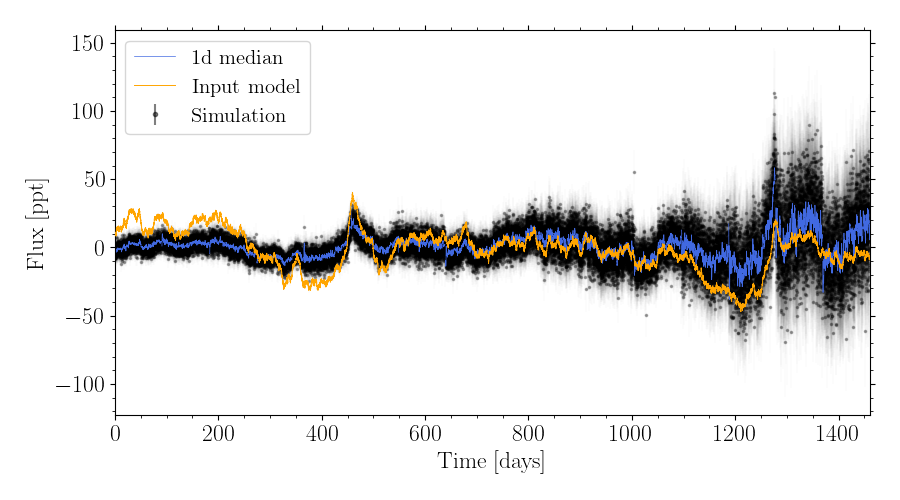

In [28]:
# Plot reduced light curve
fig = plt.figure(figsize=(9,5))
time = df.time / 86400
flux = (df.flux - 1) * 1e3
ferr = df.flux_err * 1e3
fmed = (df.flux_med - 1) * 1e3
plt.errorbar(time.iloc[0], flux.iloc[0], yerr=ferr.iloc[0], fmt='.k', alpha=0.5, label=r'Simulation', zorder=1)
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.01, zorder=1)
plt.plot(time,    flux,    '.', c='k', ms=3, alpha=0.3)
plt.plot(time,    fmed,    '-', c='royalblue', lw=0.5, label='1d median', zorder=2)
plt.plot(dv.time, dv.flux, '-', c='orange', lw=0.7, label='Input model', zorder=3)
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(0, time.max())
plt.legend(loc='best')
plt.tight_layout()

In [29]:
# Save light curve
dx = pd.DataFrame()
dx['time'] = df.time / 86400    # [day]
dx['flux'] = df.flux / 1e3 + 1  # [pp1]
dx.to_feather(sdir / f'finals/lc_{filename}.ftr')
# Save figure
fig.savefig(fdir / f'lc_{filename}.png', bbox_inches='tight', dpi=300)
# Save simulation table
filename_tab = sdir / f'finals/table_{filename}.ftr'
dt = lcs.stat_sim_table(ofile=filename_tab, clean=True, verbose=True)

100%|██████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.53


In [33]:
dt.SPR.mean() * 100

2.4098087674457243

---
## Plot for thesis
---

### Post-process a single camera light curve

In [21]:
# Load light curves of a single camera
lcs = LightCurve(odir, mode="multi")
files = lcs.files('hdf5', group=1, camera=1)

In [22]:
# Merge all quarters
df0 = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1['time'] = lc.time()
    df1['flux'] = lc.flux(unit='norm')
    df0 = pd.concat([df0, df1])
    
# Deep copy of base flux
df0['flux_base'] = df0.flux

# Stitch and detrend the light curves
lc = LightCurve(df0, mode="multi")
df = lc.stitch(method='lowess', segment=10)
df = lc.detrend(column='flux_stitch', model='poly', poly_degree=1)

# Prepare for plot
dex = [13004, 26009, 39014, 52019, 65024, 78029, 91034, 104039, 117044, 130049, 143054]
df0['flux_base_filt'] = median_filter(df0.flux_base, 240)
flux_detrend = (df.flux_detrend-1)*1e6
flux_detrend_filt = median_filter(flux_detrend, 240)
time = df.time/86400

<IPython.core.display.Javascript object>


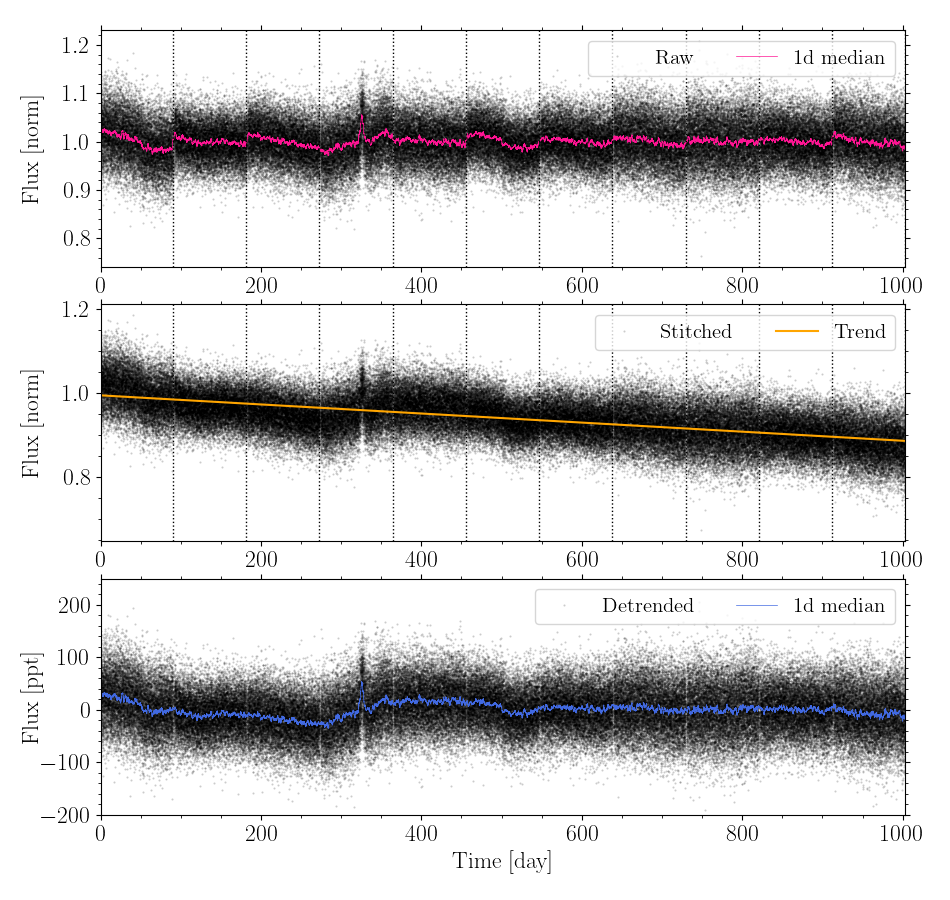

In [16]:
# Produce combined post-processing figure
fig, ax = plt.subplots(3, 1, figsize=(9.5, 9.0))

ax[0].plot(time, df0.flux_base, '.', c='k', ms=1, alpha=0.2, label='Raw')
ax[0].plot(time, df0.flux_base_filt, '-', c='deeppink', lw=0.5, label="1d median")
for i in dex: ax[0].axvline(x=time.iloc[i], c='k', linestyle=':', lw=1)
ax[0].set_ylabel('Flux [norm]')

ax[1].plot(time, df.flux_stitch, '.', c='k', ms=1, alpha=0.2, label='Stitched')
for i in dex: ax[1].axvline(x=time.iloc[i], c='k', linestyle=':', lw=1)
ax[1].plot(time, df.flux_trend, '-', c='orange', lw=1.5, alpha=1, label='Trend')
ax[1].set_ylabel('Flux [norm]')

ax[2].plot(time, flux_detrend, '.', c='k', ms=1, alpha=0.2, label='Detrended')
ax[2].plot(time, flux_detrend_filt, '-', c='royalblue', lw=0.5, label="1d median")
# ax[2].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[2].set_ylabel('Flux [ppt]')
ax[2].set_xlabel('Time [day]')
ax[2].set_ylim(-200, 250)

for i in range(3):
    ax[i].set_xlim(0, time.max())
    ax[i].legend(loc='upper right', ncol=3)
    ax[i].get_yaxis().set_label_coords(-0.07, 0.5)
plt.tight_layout(h_pad=0.1);

# Save figure
# fig.savefig(f'{fdir}/lc_pipeline.png', bbox_inches='tight', dpi=300)

### Spikey light curve

In [19]:
# Load variable source file and add flux column [ppt]
varfile = path / 'varsource/varsource_spikey_fiducial.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400

In [25]:
# Light curve of Spikey
lcs = LightCurve(sdir / 'thesis/spikey', mode="multi")
df = merge(lcs)
time = df.time / 86400

<IPython.core.display.Javascript object>


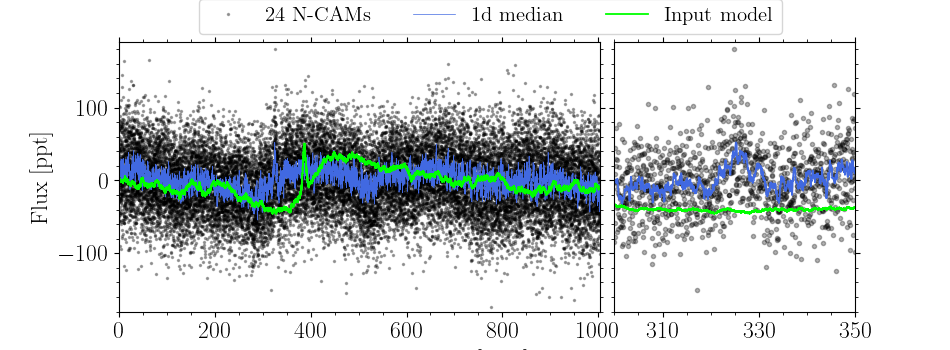

Text(0.5, -0.05, 'Time [days]')

In [27]:
# Plot light curve of Spikey
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.04}, figsize=(9.5, 3.5))

ax0.plot(time, df.flux, '.', c='k', ms=3, alpha=0.3, label=r'24 N-CAMs')
ax0.plot(time, df.fmed, '-', c='royalblue', lw=0.5, label='1d median')
ax0.plot(dv.time, dv.flux, '-', c='lime', lw=1.3, label='Input model')
ax0.set_ylabel('Flux [ppt]')
ax0.set_xlim(0, time.max())
ax0.set_ylim(-180, 190)
ax0.legend(loc='upper right', ncol=3, bbox_to_anchor=(1.4, 1.2))

ax1.plot(time, df.flux, 'o', c='k', ms=3, alpha=0.3, label=r'Spikey observed with 24 N-CAMs')
ax1.plot(time, df.fmed, '-', c='royalblue', lw=1.3)
ax1.plot(dv.time, dv.flux, '-', c='lime', lw=1.3)
ax1.set_xlim(300, 350)
ax1.set_ylim(-180, 190)
ax1.set_xticks([310, 330, 350])
ax1.set_yticklabels([])

plt.tight_layout()
fig.text(0.5, -0.05, 'Time [days]', ha='center')

# Save figure
# fig.savefig(f'{fdir}/lc_spikey.png', bbox_inches='tight', dpi=300)

### Spikey at different magnitudes

In [10]:
# Load
lcs_mag16 = LightCurve(sdir / 'thesis/000000001_mag16', mode="multi")
lcs_mag17 = LightCurve(sdir / 'thesis/000000001_mag17', mode="multi")
lcs_mag18 = LightCurve(sdir / 'thesis/000000001_mag18', mode="multi")
lcs_mag19 = LightCurve(sdir / 'thesis/000000001_mag19', mode="multi")

# Reduce light curves
df_mag16 = merge(lcs_mag16)
df_mag17 = merge(lcs_mag17)
df_mag18 = merge(lcs_mag18)
df_mag19 = merge(lcs_mag19)

# Single time array
time = df_mag16.time / 86400

100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.14
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.15
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.16
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.13


<IPython.core.display.Javascript object>


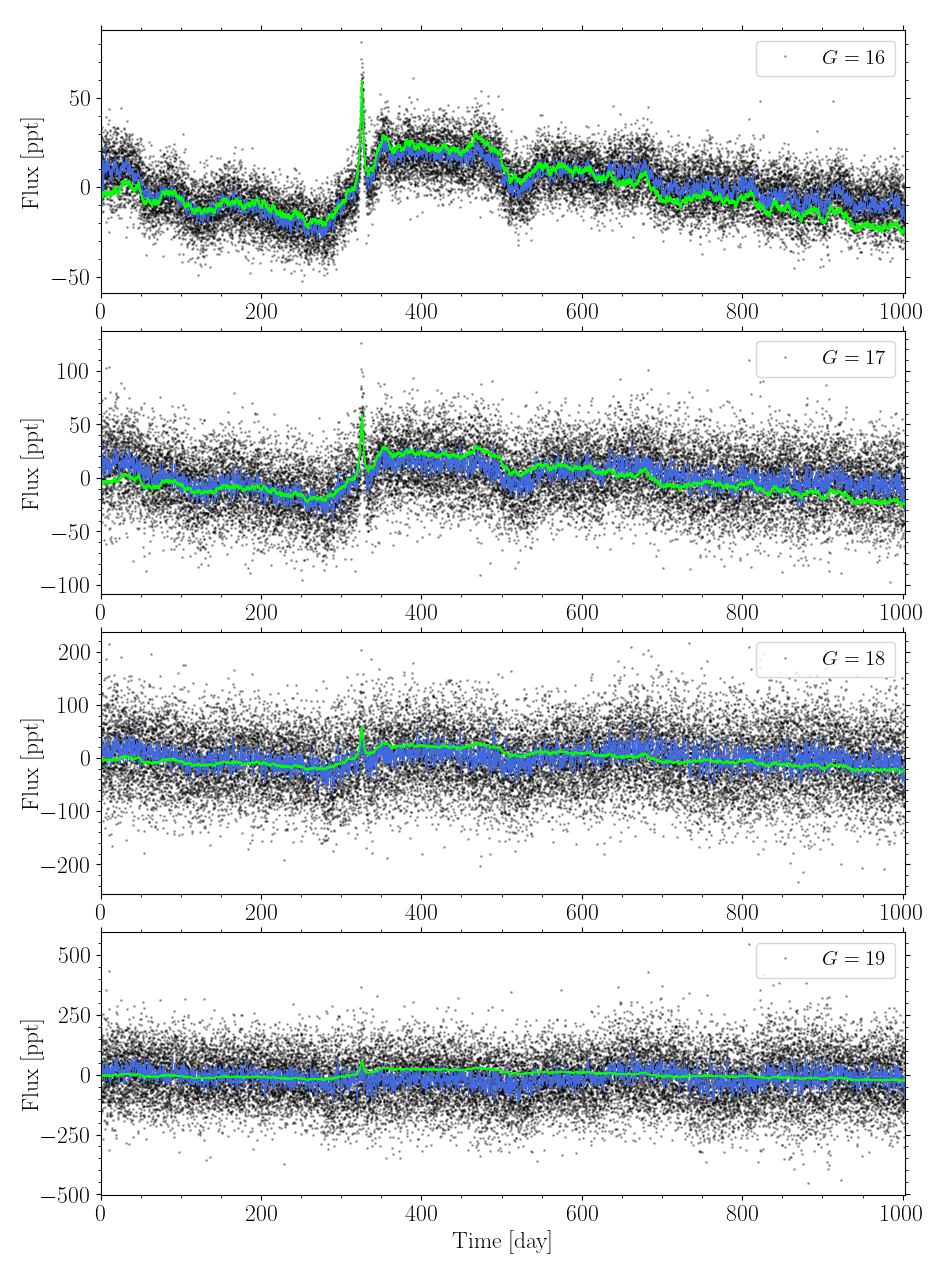

In [36]:
# Plot magnitude dependence of Spikey
fig, ax = plt.subplots(4, 1, figsize=(9.5, 12.8))

ax[0].plot(time, df_mag16.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=16$')
ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
ax[0].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[0].set_ylabel('Flux [ppt]')

ax[1].plot(time, df_mag17.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=17$')
ax[1].plot(time, df_mag17.fmed, '-', c='royalblue', lw=0.5)
ax[1].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[1].set_ylabel('Flux [ppt]')

ax[2].plot(time, df_mag18.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=18$')
ax[2].plot(time, df_mag18.fmed, '-', c='royalblue', lw=0.5)
ax[2].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[2].set_ylabel('Flux [ppt]')

ax[3].plot(time, df_mag19.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=19$')
ax[3].plot(time, df_mag19.fmed, '-', c='royalblue', lw=0.5)
ax[3].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[3].set_ylabel('Flux [ppt]')
ax[3].set_xlabel('Time [day]')

for i in range(4):
    ax[i].set_xlim(0, time.max())
    ax[i].legend(loc='upper right')
    ax[i].get_yaxis().set_label_coords(-0.07, 0.5)
plt.tight_layout(h_pad=0.1);

# Save figure
# fig.savefig(f'{fdir}/lc_magnitudes.png', bbox_inches='tight', dpi=300)

In [14]:
# def merge(lcs):
#     # Combine the two datasets while reducing each
#     dx = pd.DataFrame()
#     for g,c in zip(tqdm(range(1,5), bar_format=ut.tqdmBar()), range(1,7)):

#         files = lcs.files('hdf5', group=g, camera=c)

#         # Merge all quarters
#         df0 = pd.DataFrame()
#         df1 = pd.DataFrame()
#         for f in files:
#             lc = LightCurve(f)
#             df1['time'] = lc.time()
#             df1['flux'] = lc.flux(unit='norm')
#             df0 = pd.concat([df0, df1])

#         # Deep copy of base flux
#         df0['flux_base'] = df0.flux

#         # Stitching
#         lc = LightCurve(df0, mode="multi")
#         df = lc.stitch(method='lowess', segment=5)

#         # Detrending
#         df = lc.detrend(column='flux_stitch', model='poly', poly_degree=1)
#         df.flux_detrend = (df.flux_detrend-1)*1e6

#         # Add median filter [1 h]
#         df['flux_detrend_med'] = median_filter(df.flux_detrend, 144)
    
#         # Merge light curve
#         dx = pd.concat([dx, df])

#     # Group after timings 
#     dx = dx.groupby('time').mean().reset_index()
    
#     # Bin data [1 h]
#     tbin = int(3600)
#     tdur = dx.time.iloc[-1] - dx.time.iloc[0]
#     bins = int(tdur/tbin)
#     flux_bin, time_bin, _= binned_statistic(dx.time, dx.flux_detrend, 'median', bins)
#     flux_med, time_bin, _= binned_statistic(dx.time, dx.flux_detrend_med, 'median', bins)
#     time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.
#     dx = pd.DataFrame({'time':time_bin, 'flux':flux_bin, 'fmed':flux_med})
    
#     return dx